In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
#Exploracion y preparacion de los datos
inventories = pd.read_csv('workspace/superstore_dataset2012.csv')
inventories.info
inventories.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

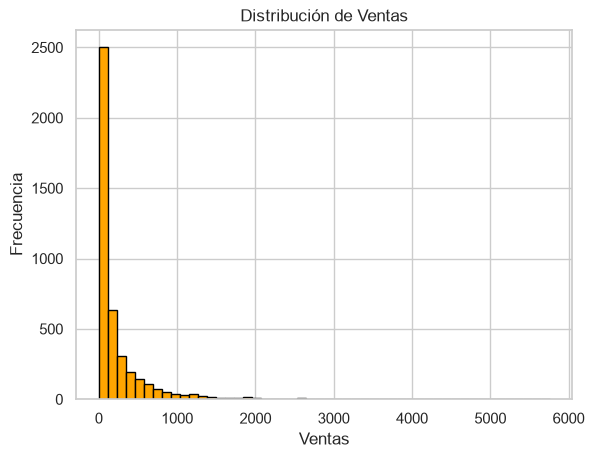

In [33]:
#Visualizaciones univariantes con Matplotlib
inventories['Sales'].hist(bins=50, color='orange', edgecolor='black')
plt.title('Distribución de Ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

#En el grafico anterior se puede observar que el volumen del negocio se sostiene gracias a una enorme cantidad de compras pequeñas y cotidianas, complementada esporádicamente por unas cuantas compras de gran valor

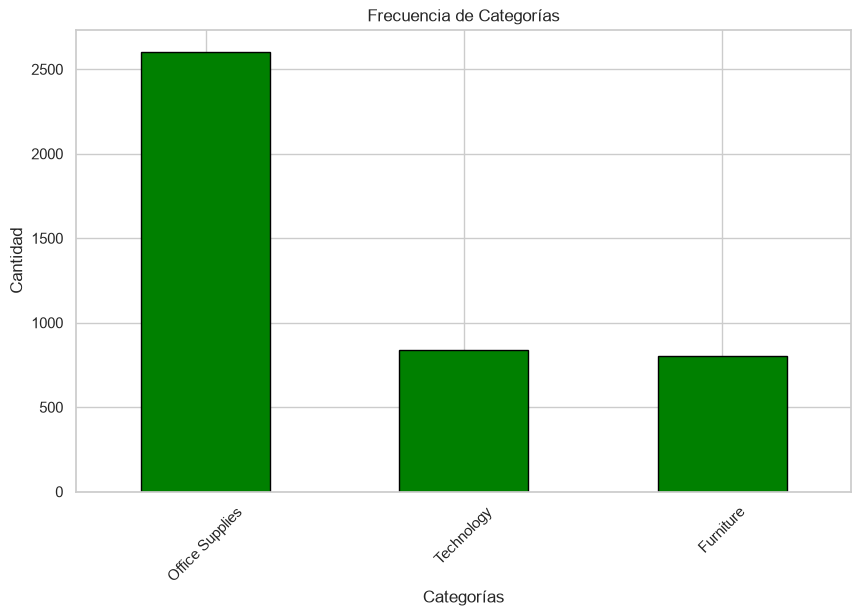

In [34]:
inventories['Category'].value_counts().plot(kind='bar', color='green', edgecolor='black', figsize=(10, 6))

plt.title('Frecuencia de Categorías')
plt.xlabel('Categorías')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

#En el grafico anterior la categoría Office Supplies lidera masivamente el negocio con más de 2,500 órdenes

C:\Users\Rigoberto\AppData\Local\Temp\ipykernel_11816\2596585720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=inventories, x='Category', y='Sales', palette='Set2')


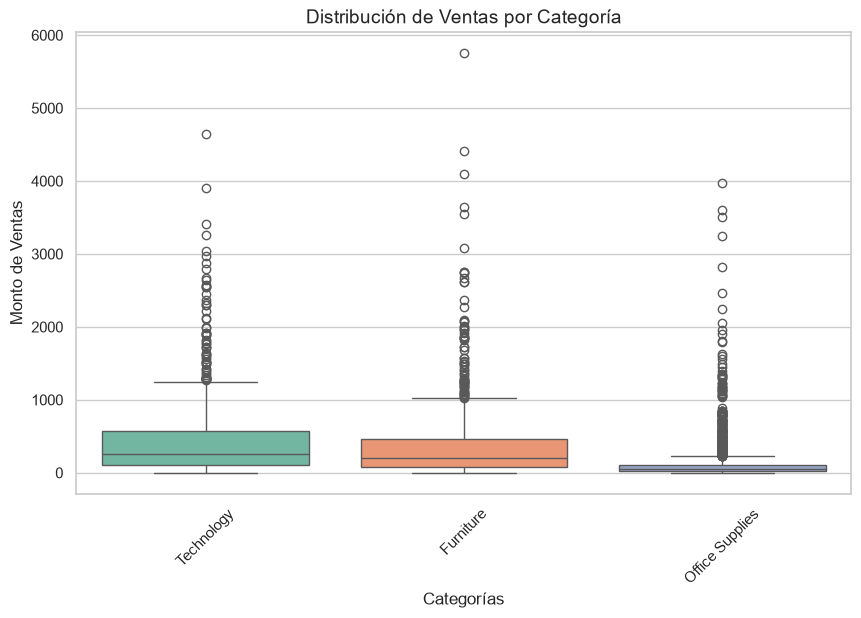

In [35]:
#Visualizaciones univariantes con Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=inventories, x='Category', y='Sales', palette='Set2')
plt.title('Distribución de Ventas por Categoría', fontsize=14)
plt.xlabel('Categorías', fontsize=12)
plt.ylabel('Monto de Ventas', fontsize=12)
plt.xticks(rotation=45)
plt.show()

#En el grafico anterior boxplot para la categoria de office supplies se puede ver que la caja es casi plana confirmando asi que el monto promedio por venta es bajo, hay mucha venta por volumen pero de muy poco valor unitario, todas las categorias muestran una enorme cantidad de puntos sueltos, dichos valores atipicos "outliers" tienen un impacto en los ingresos totales del negocio

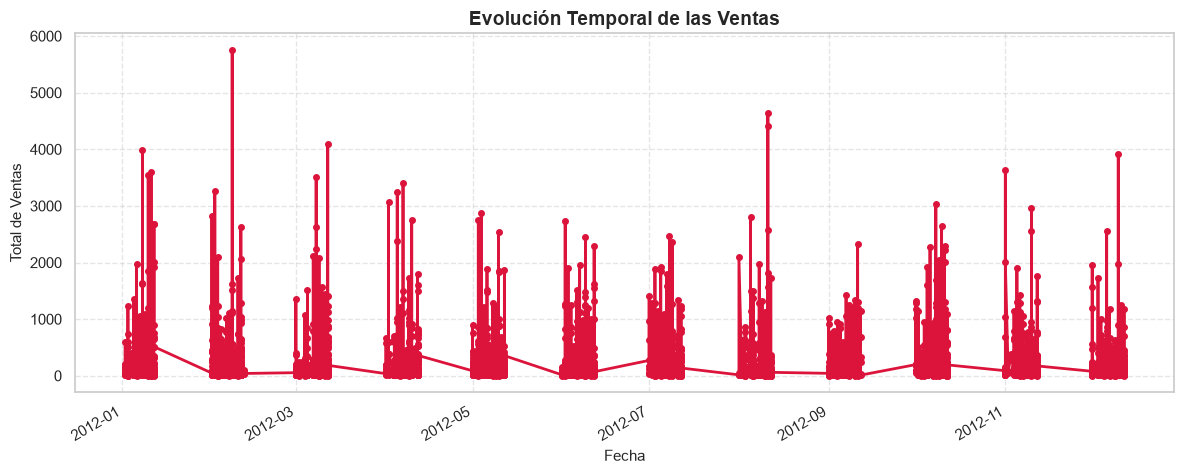

In [36]:
# Gráficos bivariantes con Matplotlib

inventories['Order Date'] = pd.to_datetime(inventories['Order Date'])
inventories = inventories.sort_values('Order Date')
plt.figure(figsize=(12, 5))
plt.plot(inventories['Order Date'], inventories['Sales'], color='crimson', linewidth=2, marker='o', markersize=4)
plt.title('Evolución Temporal de las Ventas', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Total de Ventas', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.gcf().autofmt_xdate() 
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


#En el grafico anterior la visualizacion revela picos drasticos y aislados, valles pronunciados  y estacionalidad o ciclos periodicos esto ultimo sugiere que las compras se concentran en ciertos momentos del mes

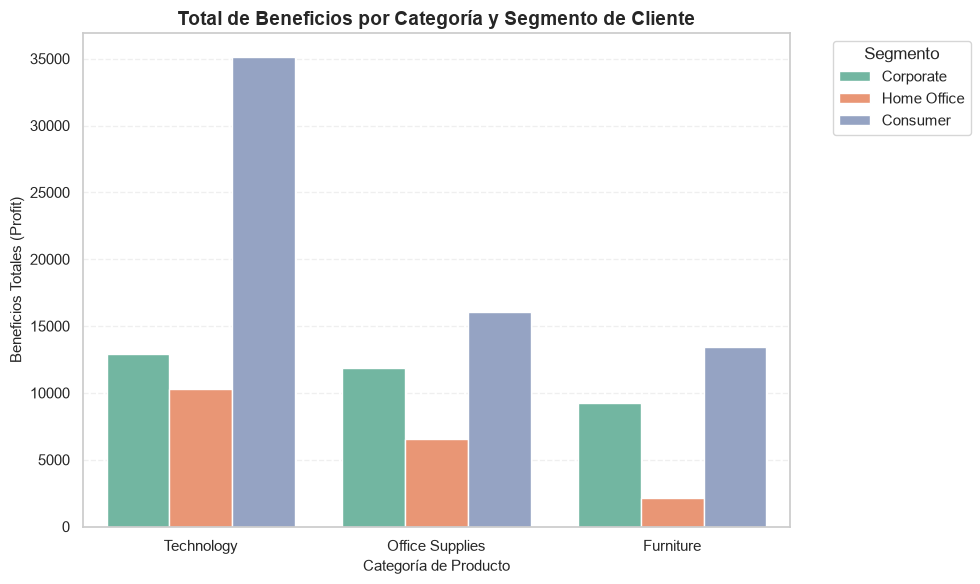

In [37]:
# Gráficos bivariantes con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=inventories, 
    x='Category', 
    y='Profit', 
    hue='Segment',      
    estimator=sum,    
    errorbar=None, 
    palette='Set2'
)
plt.title('Total de Beneficios por Categoría y Segmento de Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Producto', fontsize=11)
plt.ylabel('Beneficios Totales (Profit)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#El grafico anterior revela la rentabilidad real del negocio al cruzar las categorías con los segmentos de clientes

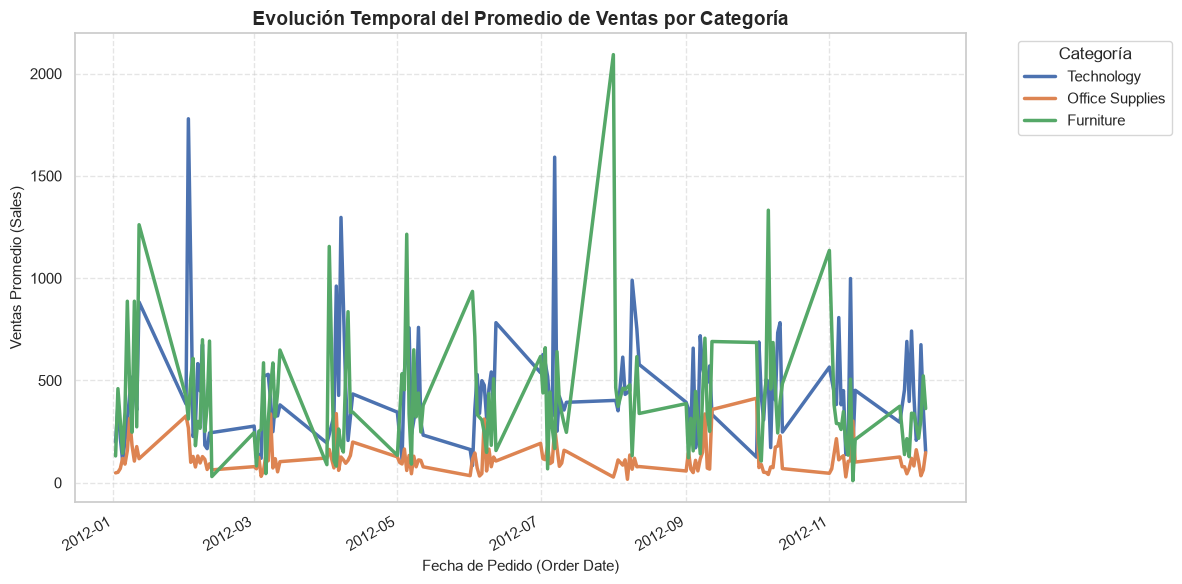

In [38]:
inventories['Order Date'] = pd.to_datetime(inventories['Order Date'])
inventories = inventories.sort_values('Order Date')
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=inventories, 
    x='Order Date', 
    y='Sales', 
    hue='Category',
    estimator='mean',
    errorbar=None,
    linewidth=2.5
)
plt.title('Evolución Temporal del Promedio de Ventas por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Fecha de Pedido (Order Date)', fontsize=11)
plt.ylabel('Ventas Promedio (Sales)', fontsize=11)
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#El grafico anterior revela cómo evoluciona el promedio de las ventas a lo largo del tiempo: La línea naranja se mantiene constantemente en la parte baja del gráfico su promedio de venta por transacción es bajo, pero es una línea de negocio sumamente predecible, lineal y sin caídas drásticas.  Las líneas azul y verde tienen un comportamiento sumamente volátil

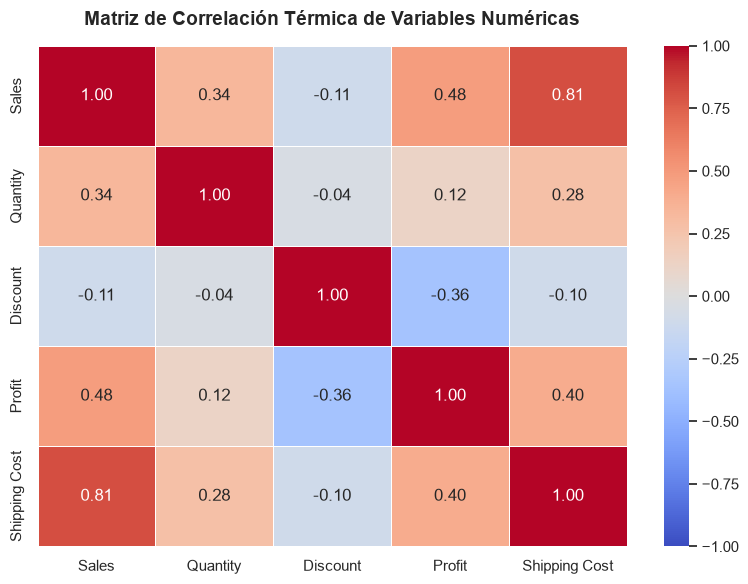

In [39]:
#Visualización multivariante con Seaborn
columnas_numericas = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
matriz_correlacion = inventories[columnas_numericas].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1 
)
plt.title('Matriz de Correlación Térmica de Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#El grafico anterior (heatmap) revela de forma directa qué variables impulsan el éxito y cuáles destruyen los márgenes

C:\Users\Rigoberto\AppData\Local\Temp\ipykernel_11816\2990169113.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=inventories, x='Ship Mode', palette='Blues_r', ax=axes[0, 1],
C:\Users\Rigoberto\AppData\Local\Temp\ipykernel_11816\2990169113.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=inventories, x='Segment', y='Profit', palette='Set2', ax=axes[1, 1])


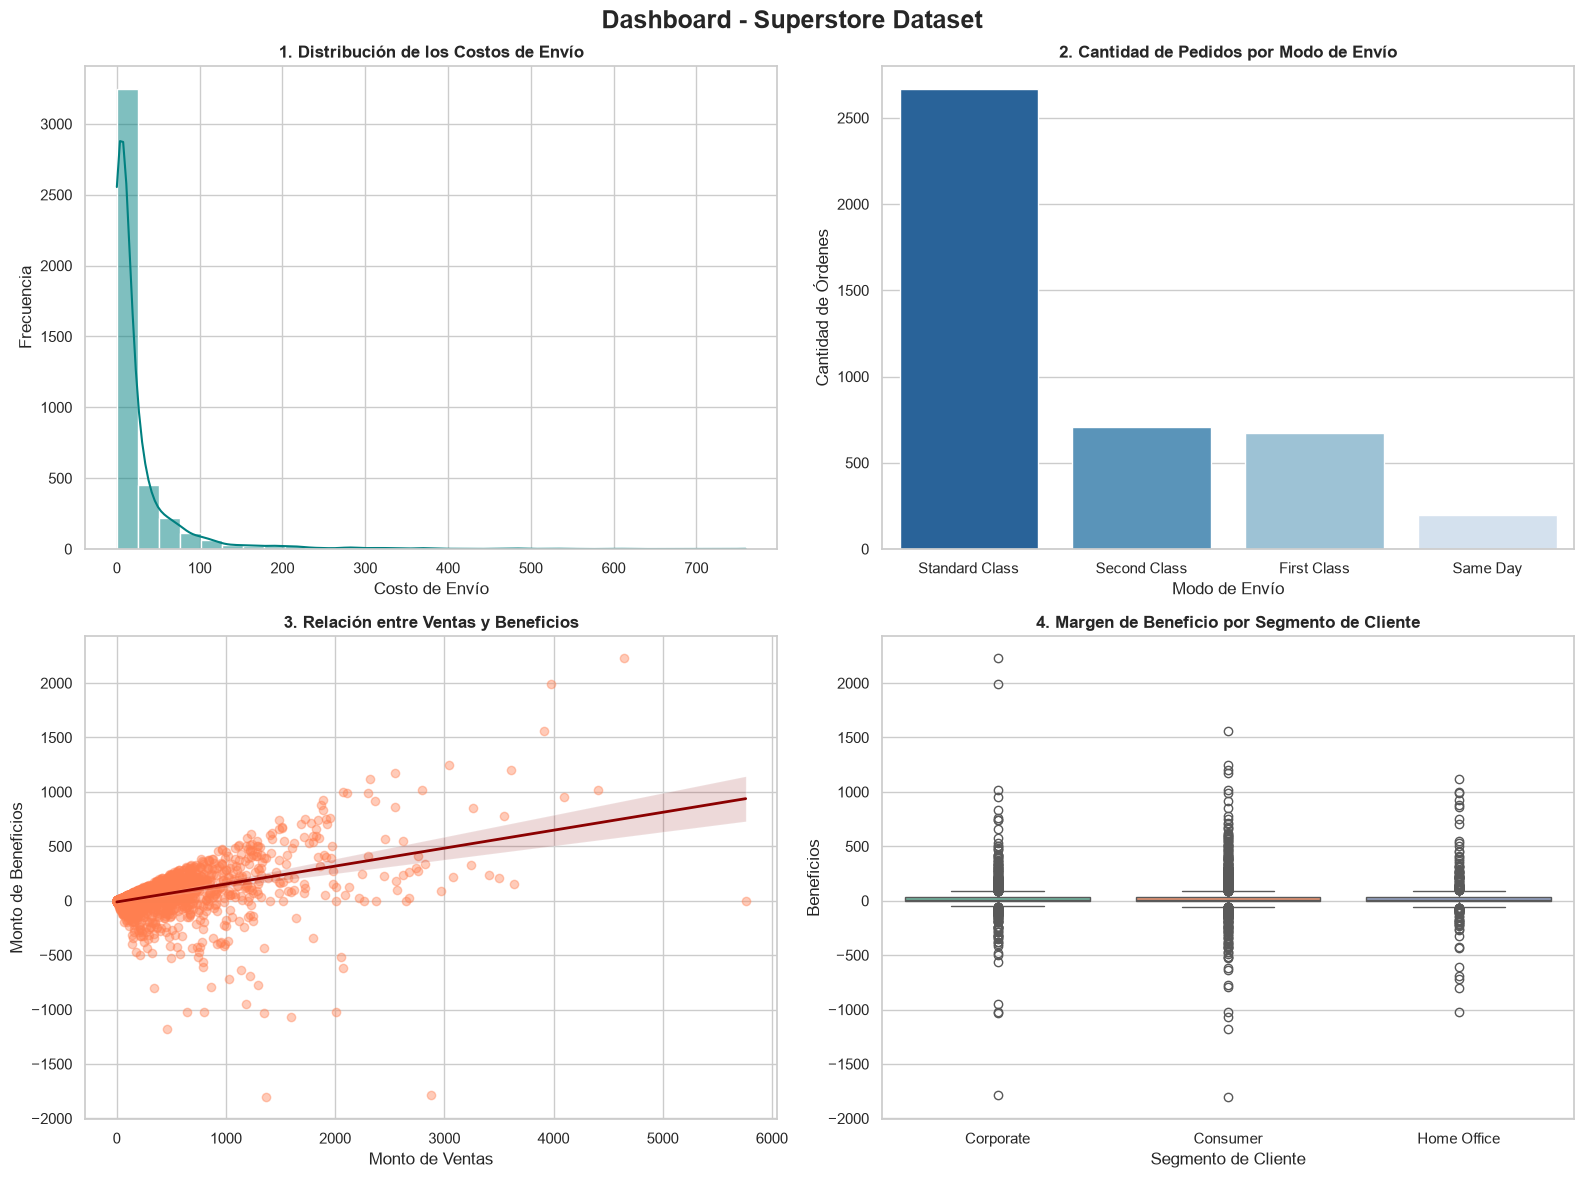

In [40]:
#SubPlots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")
# ---------------------------------------------------------------------------
# SUBPLOT 1 : Histograma de Costos de Envío
# ---------------------------------------------------------------------------
sns.histplot(data=inventories, x='Shipping Cost', kde=True, color='teal', ax=axes[0, 0], bins=30)
axes[0, 0].set_title('1. Distribución de los Costos de Envío', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Costo de Envío')
axes[0, 0].set_ylabel('Frecuencia')

# ---------------------------------------------------------------------------
# SUBPLOT 2: Gráfico de Barras (Conteo de Ship Mode)
# ---------------------------------------------------------------------------
sns.countplot(data=inventories, x='Ship Mode', palette='Blues_r', ax=axes[0, 1], 
              order=inventories['Ship Mode'].value_counts().index)
axes[0, 1].set_title('2. Cantidad de Pedidos por Modo de Envío', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Modo de Envío')
axes[0, 1].set_ylabel('Cantidad de Órdenes')

# ---------------------------------------------------------------------------
# SUBPLOT 3 : Dispersión con Regresión (Sales vs Profit)
# ---------------------------------------------------------------------------
sns.regplot(data=inventories, x='Sales', y='Profit', ax=axes[1, 0],
            scatter_kws={'alpha': 0.4, 'color': 'coral'}, 
            line_kws={'color': 'darkred', 'linewidth': 2})
axes[1, 0].set_title('3. Relación entre Ventas y Beneficios', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Monto de Ventas')
axes[1, 0].set_ylabel('Monto de Beneficios')

# ---------------------------------------------------------------------------
# SUBPLOT 4: Boxplot de Ganancias por Segmento
# ---------------------------------------------------------------------------
sns.boxplot(data=inventories, x='Segment', y='Profit', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('4. Margen de Beneficio por Segmento de Cliente', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Segmento de Cliente')
axes[1, 1].set_ylabel('Beneficios')
fig.suptitle('Dashboard - Superstore Dataset', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(
    'dashboard_superstore.png',
    dpi=300, 
    bbox_inches='tight' 
)
plt.show()

#El cuadro de control anterior (dashboard) unifica los analisis en una sola vista. En el grafico 1 y 2 la operacion logistica esta dominada de forma masiva por en envio "Standar Class" , los envios urgentes son minimos. El grafico 3 muestra una tendencia general positiva (línea roja), pero revela un foco rojo crítico: hay una cantidad alarmante de puntos en la zona inferior (por debajo de 0 beneficios). El grafico 4 las cajas centrales parecen estables y pegadas al cero lo que indica que el pedido común deja márgenes pequeños